In [1]:
import pandas as pd
from pymatgen.core import Composition
from periodic_trends import plotter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

import re
from collections import Counter

In [2]:
from plot_design import *

In [3]:
icsd_test_df = pd.read_csv("control_dataset_splits/ICSD_test_split.csv")
icsd_val_df = pd.read_csv("control_dataset_splits/ICSD_val_split.csv")
icsd_train_df = pd.read_csv("control_dataset_splits/ICSD_train_split.csv")

icsd_df = pd.concat([icsd_train_df, icsd_val_df, icsd_test_df], ignore_index=True)
print(icsd_df.shape)

(2283, 5)


# Periodic table plot

In [4]:
from bokeh.io import output_notebook

output_notebook()

Loading BokehJS ...

In [5]:
my_highlights = ["Mn", "O"]
my_color = "#30d6ff" 

import pandas as pd
pd.Series.iteritems = pd.Series.items

all_elements = []
for formula in icsd_df['Chemical']:
    comp = Composition(formula)
    all_elements.extend([el.symbol for el in comp.elements])

counts_df = pd.Series(all_elements).value_counts().reset_index()
counts_df.columns = ['Element', 'Count']


counts_df.loc[counts_df['Element'].isin(['Mn', 'O']), 'Count'] = np.nan

custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fbbe23","#e55c30", "#993bff", "#57106e"])

plotter(
    counts_df, 
    "Element", 
    "Count", 
    special_elements=my_highlights,
    special_color=my_color,
    blank_color="#fafafa",
    output_filename="table.html", 
    width = 1000,
    height = 600,
    cbar_fontsize = 16,
    cmap= custom_cmap,
    alpha= 0.9
)

figure(id='p1007', ...)

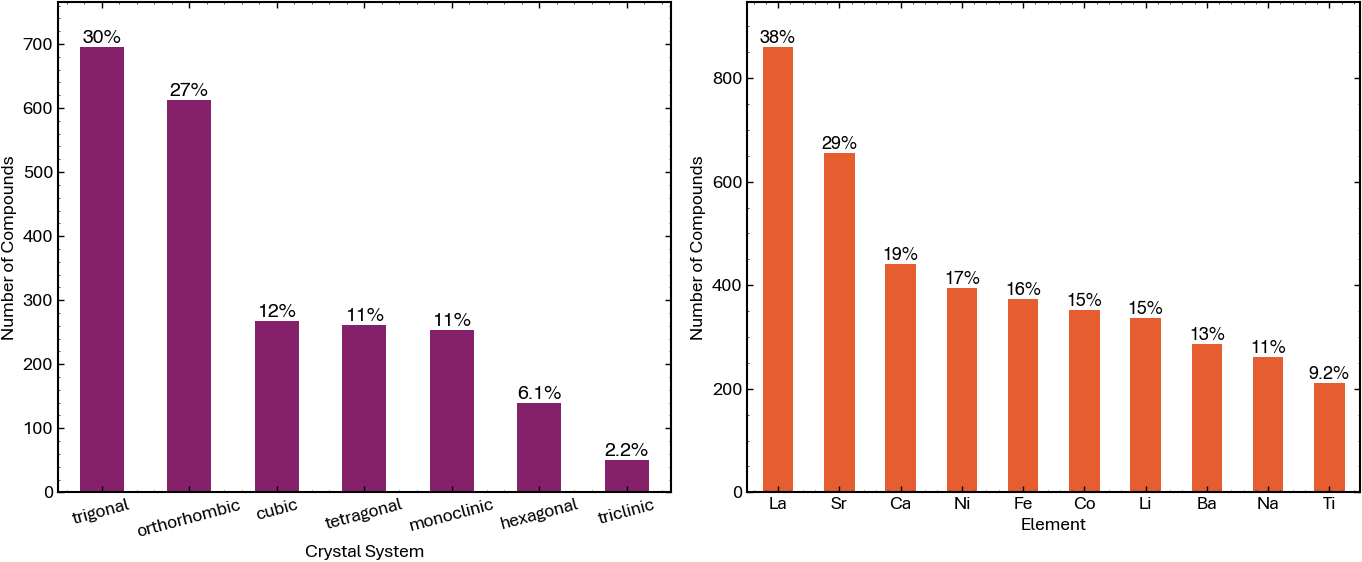

In [8]:
def get_colormap_colors(num_items, colormap='viridis', cmap_range=(0.1, 0.9)):
    cmap = plt.get_cmap(colormap)
    if num_items == 1:
        return [cmap((cmap_range[0] + cmap_range[1]) / 2)]
    else:
        return [
            cmap(cmap_range[0] + (cmap_range[1] - cmap_range[0]) * i / (num_items - 1))
            for i in range(num_items)
        ]

counts = icsd_df['Crystal_System'].value_counts()
total_compounds = len(icsd_df)
bar_colour = get_colormap_colors(4, colormap='inferno')

def get_element_counts(formulas):
    counts = Counter()
    for formula in formulas:
        elements = re.findall(r'([A-Z][a-z]*)', formula)
        for el in elements:
            counts[el] += 1
    return counts

element_counts = get_element_counts(icsd_df['Chemical'])

df_elements = (
    pd.DataFrame.from_dict(element_counts, orient='index', columns=['count'])
    .sort_values(by='count', ascending=False)
    .iloc[2:]        # ← remove the two most common elements
    .head(10)        # ← then take the next 12
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

counts.plot(kind='bar', ax=ax1, color=bar_colour[1])

for p in ax1.patches:
    percentage = f'{100 * p.get_height() / total_compounds:.2g}%'
    ax1.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=14,
        fontfamily='Helvetica'
    )

ax1.set_xlabel('Crystal System')
ax1.set_ylabel('Number of Compounds')
ax1.set_ylim(0, counts.max() * 1.1)
ax1.tick_params(axis='x', rotation = 15)

df_elements.plot(kind='bar', ax=ax2, color = bar_colour[2])

for p in ax2.patches:
    percentage = f'{100 * p.get_height() / total_compounds:.2g}%'
    ax2.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=13,
        fontfamily='Helvetica'
    )

ax2.set_xlabel('Element')
ax2.set_ylabel('Number of Compounds')
ax2.set_ylim(0, df_elements['count'].max() * 1.1)
ax2.tick_params(axis='both', rotation = 0)
ax2.legend().remove()


plt.tight_layout()
plt.show()

# Crystal system analysis

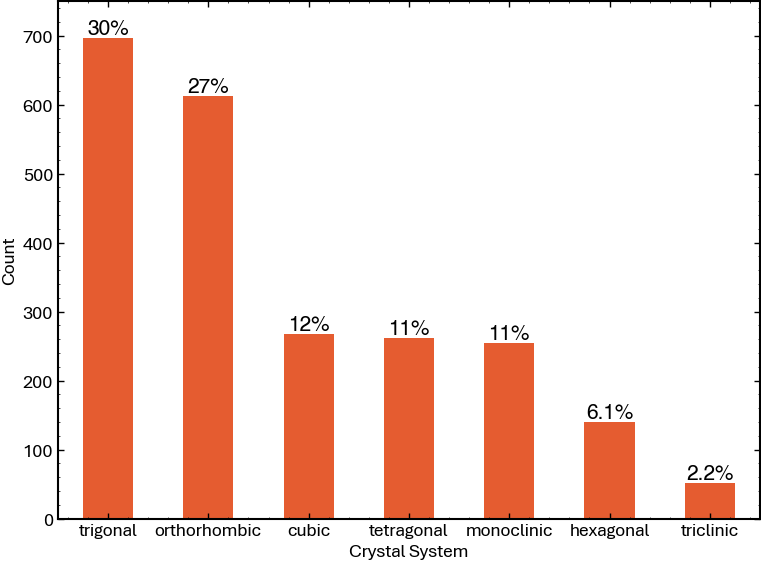

In [9]:
counts = icsd_df['Crystal_System'].value_counts()
total = len(icsd_df)

plt.figure(figsize=(8, 6))
ax = counts.plot(kind='bar', color = "#e55c30")

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2g}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=15, fontfamily = 'Helvetica')

# 4. Final plot formatting
plt.xlabel('Crystal System')
plt.ylabel('Count')
ax.set_ylim(0, 750)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

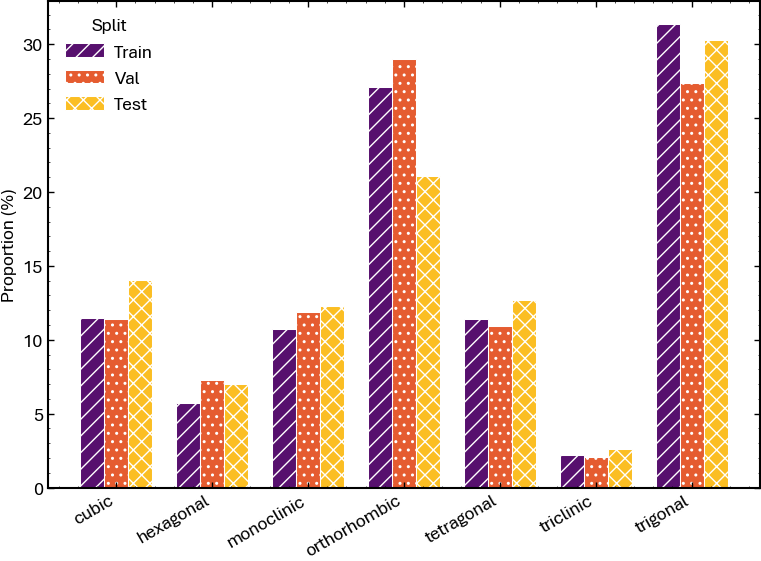

In [10]:
train_dist = icsd_train_df['Crystal_System'].value_counts(normalize=True).sort_index() * 100
val_dist   = icsd_val_df['Crystal_System'].value_counts(normalize=True).sort_index() * 100
test_dist  = icsd_test_df['Crystal_System'].value_counts(normalize=True).sort_index() * 100

crystal_systems = train_dist.index.tolist()
x = np.arange(len(crystal_systems))
width = 0.25

split_colors  = {'Train': '#57106e', 'Val': '#e55c30', 'Test': '#fbbe23'}
split_hatches = {'Train': '//',      'Val': '..',      'Test': 'xx'}

plt.figure(figsize=(8, 6))

for i, (split, dist) in enumerate(zip(
    ['Train', 'Val', 'Test'],
    [train_dist, val_dist, test_dist]
)):
    plt.bar(
        x + (i - 1) * width,
        dist.values,
        width=width,
        color=split_colors[split],
        hatch=split_hatches[split],
        edgecolor='white',
        linewidth=0.75,
        label=split
    )

plt.xticks(x, crystal_systems, rotation=30, ha='right')
plt.ylabel('Proportion (%)')
plt.legend(title='Split', frameon=False)
plt.tight_layout()
plt.savefig('class_distribution_splits.png', dpi=150, bbox_inches='tight')
plt.show()